<a href="https://colab.research.google.com/github/shahankit82/part-2-cnn-computer-vision/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1: Problem Identification

 Information has been provided into Readme.MD

Task 2: Dataset Exploration

Step 1: Extract ZIP

In [16]:
import zipfile
import os

zip_path = '/content/images-20260506T121214Z-3-001.zip'  # upload zip in Colab
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted!")

Extracted!


Step 2: Count Classes & Images

In [17]:
classes = os.listdir(extract_path)

data_summary = {}

for cls in classes:
    class_path = os.path.join(extract_path, cls)
    data_summary[cls] = len(os.listdir(class_path))

data_summary

{'images': 5}

Step 3: Show Sample Images

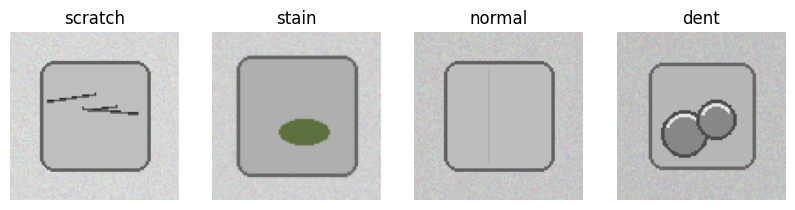

In [18]:
import matplotlib.pyplot as plt
from PIL import Image
import os # Ensure os module is imported

plt.figure(figsize=(10,5))

image_category_root = os.path.join(extract_path, classes[0])

actual_image_categories = [d for d in os.listdir(image_category_root) if os.path.isdir(os.path.join(image_category_root, d))]

num_categories_to_display = min(len(actual_image_categories), 5)

for i, category_name in enumerate(actual_image_categories[:num_categories_to_display]):
    category_path = os.path.join(image_category_root, category_name)

    image_files = [f for f in os.listdir(category_path) if os.path.isfile(os.path.join(category_path, f))]

    if image_files:
        first_image_filename = image_files[0]
        img_path = os.path.join(category_path, first_image_filename)

        try:
            img = Image.open(img_path)

            plt.subplot(1, num_categories_to_display, i+1)
            plt.imshow(img)
            plt.title(category_name)
            plt.axis('off')
        except Exception as e:
            print(f"Could not open image {img_path}: {e}")
    else:
        print(f"No image files found in category: {category_name}")

plt.show()

Step 4: Image Dimensions

In [19]:
img = Image.open(img_path)
print(img.size)  # (width, height)

(96, 96)


Step 5: Check Imbalance

<Axes: title={'center': 'Class Distribution'}, xlabel='Class'>

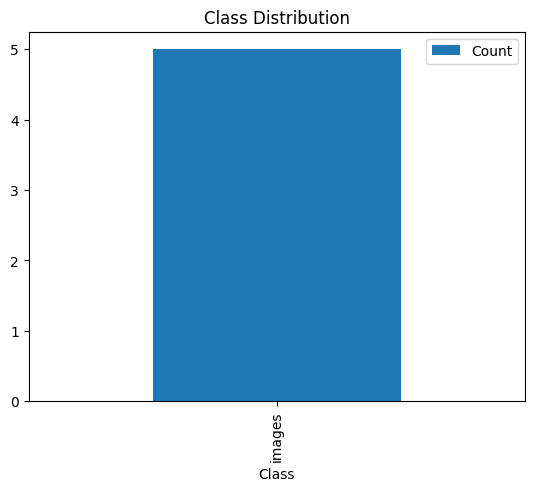

In [20]:
import pandas as pd

df_counts = pd.DataFrame(list(data_summary.items()), columns=['Class','Count'])
df_counts.plot(kind='bar', x='Class', y='Count', title='Class Distribution')

Task 3: Image Preprocessing

Use Keras ImageDataGenerator

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_datagen.flow_from_directory(
    extract_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    extract_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 384 images belonging to 1 classes.
Found 96 images belonging to 1 classes.


Task 4: CNN Model Creation

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(train_data.num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

Task 5: Training & Evaluation

 Train

In [23]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/losses/losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 647ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 570ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 622ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 588ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 637ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 667ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 555ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 604ms/step - accur

Plot Accuracy & Loss

Text(0.5, 1.0, 'Loss')

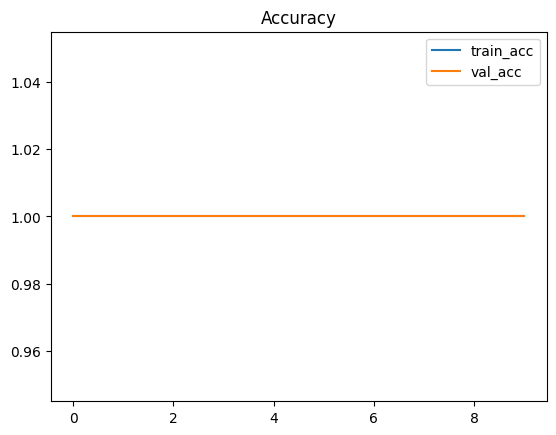

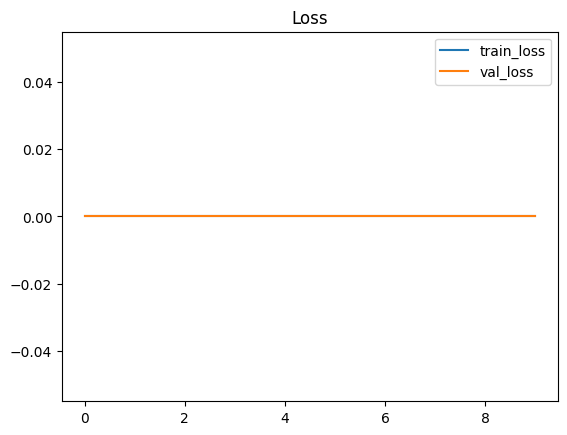

In [24]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")

plt.figure()
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")

Confusion Matrix

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 252ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


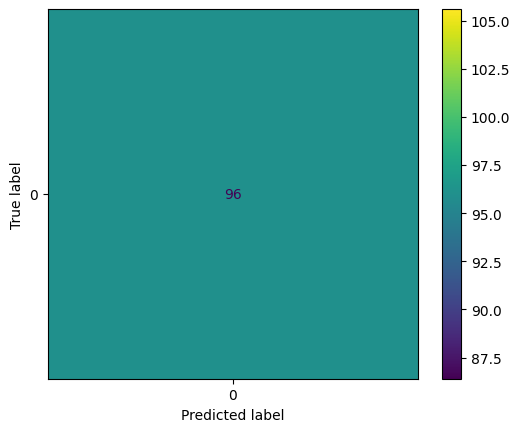

In [25]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(val_data.classes, y_pred_classes)

ConfusionMatrixDisplay(cm).plot()
plt.show()

Sample Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step


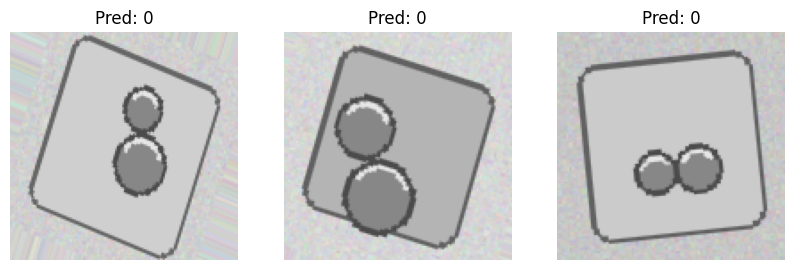

In [26]:
plt.figure(figsize=(10,5))

for i in range(min(5, len(val_data))):
    img, label = val_data[i]
    pred = model.predict(img)

    plt.subplot(1, min(5, len(val_data)), i+1)
    plt.imshow(img[0])
    plt.title(f"Pred: {np.argmax(pred)}")
    plt.axis('off')

plt.show()